# LVIS footprints and rasters mapped in ABoVE domain

refs:
+ lvis_footprints_geo.ipynb
+ above_lidar_check.ipynb
+ s3_data_access_LVIS.ipynb
+ arcticdem_stac_api_workflow.ipynb

In [1]:
library(tidyverse)
library(sf)
library(ggspatial)
library(terra)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE

terra 1.7.78


Attaching package: ‘terra’


The following object is masked from ‘package:tidyr’:

    extract




In [2]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:terra’:

    area




In [3]:
library(RColorBrewer)
library(viridis)

Loading required package: viridisLite



In [4]:
OUTDIR = '/projects/my-public-bucket/above_lvis_flightlines/paper_figs'

In [5]:
source('/projects/code/3dsi/boreal_map_functions.R')


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"



Attaching package: ‘data.table’


The following object is masked from ‘package:terra’:

    shift


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:terra’:

    rescale


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [6]:
lvis_footprints_2017 = st_read('/projects/my-public-bucket/databank/footprints/LVIS_ABoVE_spatial_footprints_2017_2019.gpkg', layer='LVISF2_2017')
lvis_footprints_2017$campaign = 'LVISF2 2017'
lvis_footprints_2019 = st_read('/projects/my-public-bucket/databank/footprints/LVIS_ABoVE_spatial_footprints_2017_2019.gpkg', layer='LVISF2_2019')
lvis_footprints_2019$campaign = 'LVISF2 2019'

Reading layer `LVISF2_2017' from data source 
  `/projects/my-public-bucket/databank/footprints/LVIS_ABoVE_spatial_footprints_2017_2019.gpkg' 
  using driver `GPKG'
Simple feature collection with 1051 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -4410508 ymin: 979969.9 xmax: -794565.1 ymax: 2521179
Projected CRS: WGS 84 / Arctic Polar Stereographic
Reading layer `LVISF2_2019' from data source 
  `/projects/my-public-bucket/databank/footprints/LVIS_ABoVE_spatial_footprints_2017_2019.gpkg' 
  using driver `GPKG'
Simple feature collection with 2528 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -10418580 ymin: -1133176 xmax: -623602.1 ymax: 3292948
Projected CRS: WGS 84 / Arctic Polar Stereographic


In [7]:
lvis_footprints = rbind(lvis_footprints_2017, lvis_footprints_2019)
lvis_footprints$`Deployment` = lvis_footprints$campaign

In [8]:
colnames(lvis_footprints)

[1] "DN"         "FILE"       "PATH"       "campaign"   "geom"      
[6] "Deployment"

In [9]:
above_field_points = data.frame(read.csv('/projects/my-public-bucket/above_lvis_flightlines/data/ABoVE_Planning_Field_Sites_1582/data/above_airborne_campaign_point_locations.csv')) %>% 
    st_as_sf(coords=c("point_x","point_y"), crs=4326)

In [10]:
above_domain = st_read(above_domain_fn) %>% st_transform(crs = crs_canalb)

Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


In [11]:
CRS_LON=-96
CRS_LON=-120

In [12]:
crs_canalb = paste0('+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=', CRS_LON,' +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs')
lvis_footprints_trans = lvis_footprints %>% st_transform(crs = crs_canalb)

In [13]:
disp_win_wgs84 <- st_sfc(st_point(c(-145, 35)), st_point(c(-40, 75)), crs = 4326)
disp_win_wgs84 <- st_sfc(st_point(c(-150, 45)), st_point(c(-72.5, 70)), crs = 4326)
disp_win_wgs84

POINT (-150 45)

POINT (-72.5 70)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



Geometry set for 2 features 
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -150 ymin: 45 xmax: -72.5 ymax: 70
Geodetic CRS:  WGS 84

In [14]:
disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
disp_win_coord <- st_coordinates(disp_win_trans)

In [15]:
theme_custom = list(
      theme_minimal(),
          annotation_scale(location = "bl", style="ticks") ,
          annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    )

In [16]:
above_field_points$simple_name = 'ABoVE Ground Plots '
head(above_field_points)

,name,region,data_type,PI,PI_email,archive,data_link1,data_link2,tower_type,project_profile1,project_profile2,project_profile3,layer_name,PI_v2,geometry,simple_name
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<POINT [°]>,<chr>
1,SS3-104-1,"Northwest Territories, Canada",Fire disturbance related ground data,ABoVE Disturbance Working Group,"michelle.mack@nau.edu (Mack, Michelle as the Fire Working Group Lead)",ORNL DAAC (planned),https://daac.ornl.gov/,N/A,N/A,https://above.nasa.gov/implementation_plan/disturbancewg.html,N/A,N/A,Fire WG Priorities,ABoVE Disturbance Working Group,POINT (-117.404 60.93871),ABoVE Ground Plots
2,SS3-104-2,"Northwest Territories, Canada",Fire disturbance related ground data,ABoVE Disturbance Working Group,"michelle.mack@nau.edu (Mack, Michelle as the Fire Working Group Lead)",ORNL DAAC (planned),https://daac.ornl.gov/,N/A,N/A,https://above.nasa.gov/implementation_plan/disturbancewg.html,N/A,N/A,Fire WG Priorities,ABoVE Disturbance Working Group,POINT (-117.4041 60.93853),ABoVE Ground Plots
3,SS3-104-3,"Northwest Territories, Canada",Fire disturbance related ground data,ABoVE Disturbance Working Group,"michelle.mack@nau.edu (Mack, Michelle as the Fire Working Group Lead)",ORNL DAAC (planned),https://daac.ornl.gov/,N/A,N/A,https://above.nasa.gov/implementation_plan/disturbancewg.html,N/A,N/A,Fire WG Priorities,ABoVE Disturbance Working Group,POINT (-117.404 60.93836),ABoVE Ground Plots
4,SS3-104-5,"Northwest Territories, Canada",Fire disturbance related ground data,ABoVE Disturbance Working Group,"michelle.mack@nau.edu (Mack, Michelle as the Fire Working Group Lead)",ORNL DAAC (planned),https://daac.ornl.gov/,N/A,N/A,https://above.nasa.gov/implementation_plan/disturbancewg.html,N/A,N/A,Fire WG Priorities,ABoVE Disturbance Working Group,POINT (-117.4049 60.93858),ABoVE Ground Plots
5,SS3-104-6,"Northwest Territories, Canada",Fire disturbance related ground data,ABoVE Disturbance Working Group,"michelle.mack@nau.edu (Mack, Michelle as the Fire Working Group Lead)",ORNL DAAC (planned),https://daac.ornl.gov/,N/A,N/A,https://above.nasa.gov/implementation_plan/disturbancewg.html,N/A,N/A,Fire WG Priorities,ABoVE Disturbance Working Group,POINT (-117.4049 60.9384),ABoVE Ground Plots
6,SS3-109-1,"Northwest Territories, Canada",Fire disturbance related ground data,ABoVE Disturbance Working Group,"michelle.mack@nau.edu (Mack, Michelle as the Fire Working Group Lead)",ORNL DAAC (planned),https://daac.ornl.gov/,N/A,N/A,https://above.nasa.gov/implementation_plan/disturbancewg.html,N/A,N/A,Fire WG Priorities,ABoVE Disturbance Working Group,POINT (-117.4022 60.90605),ABoVE Ground Plots


In [44]:
# options(repr.plot.width = 4, repr.plot.height = 3.5, repr.plot.res = 250)

# library(viridis)
# viridis_colors <- viridis(n = 51, option='turbo')
# print(viridis_colors)
# show_col(viridis_colors)

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


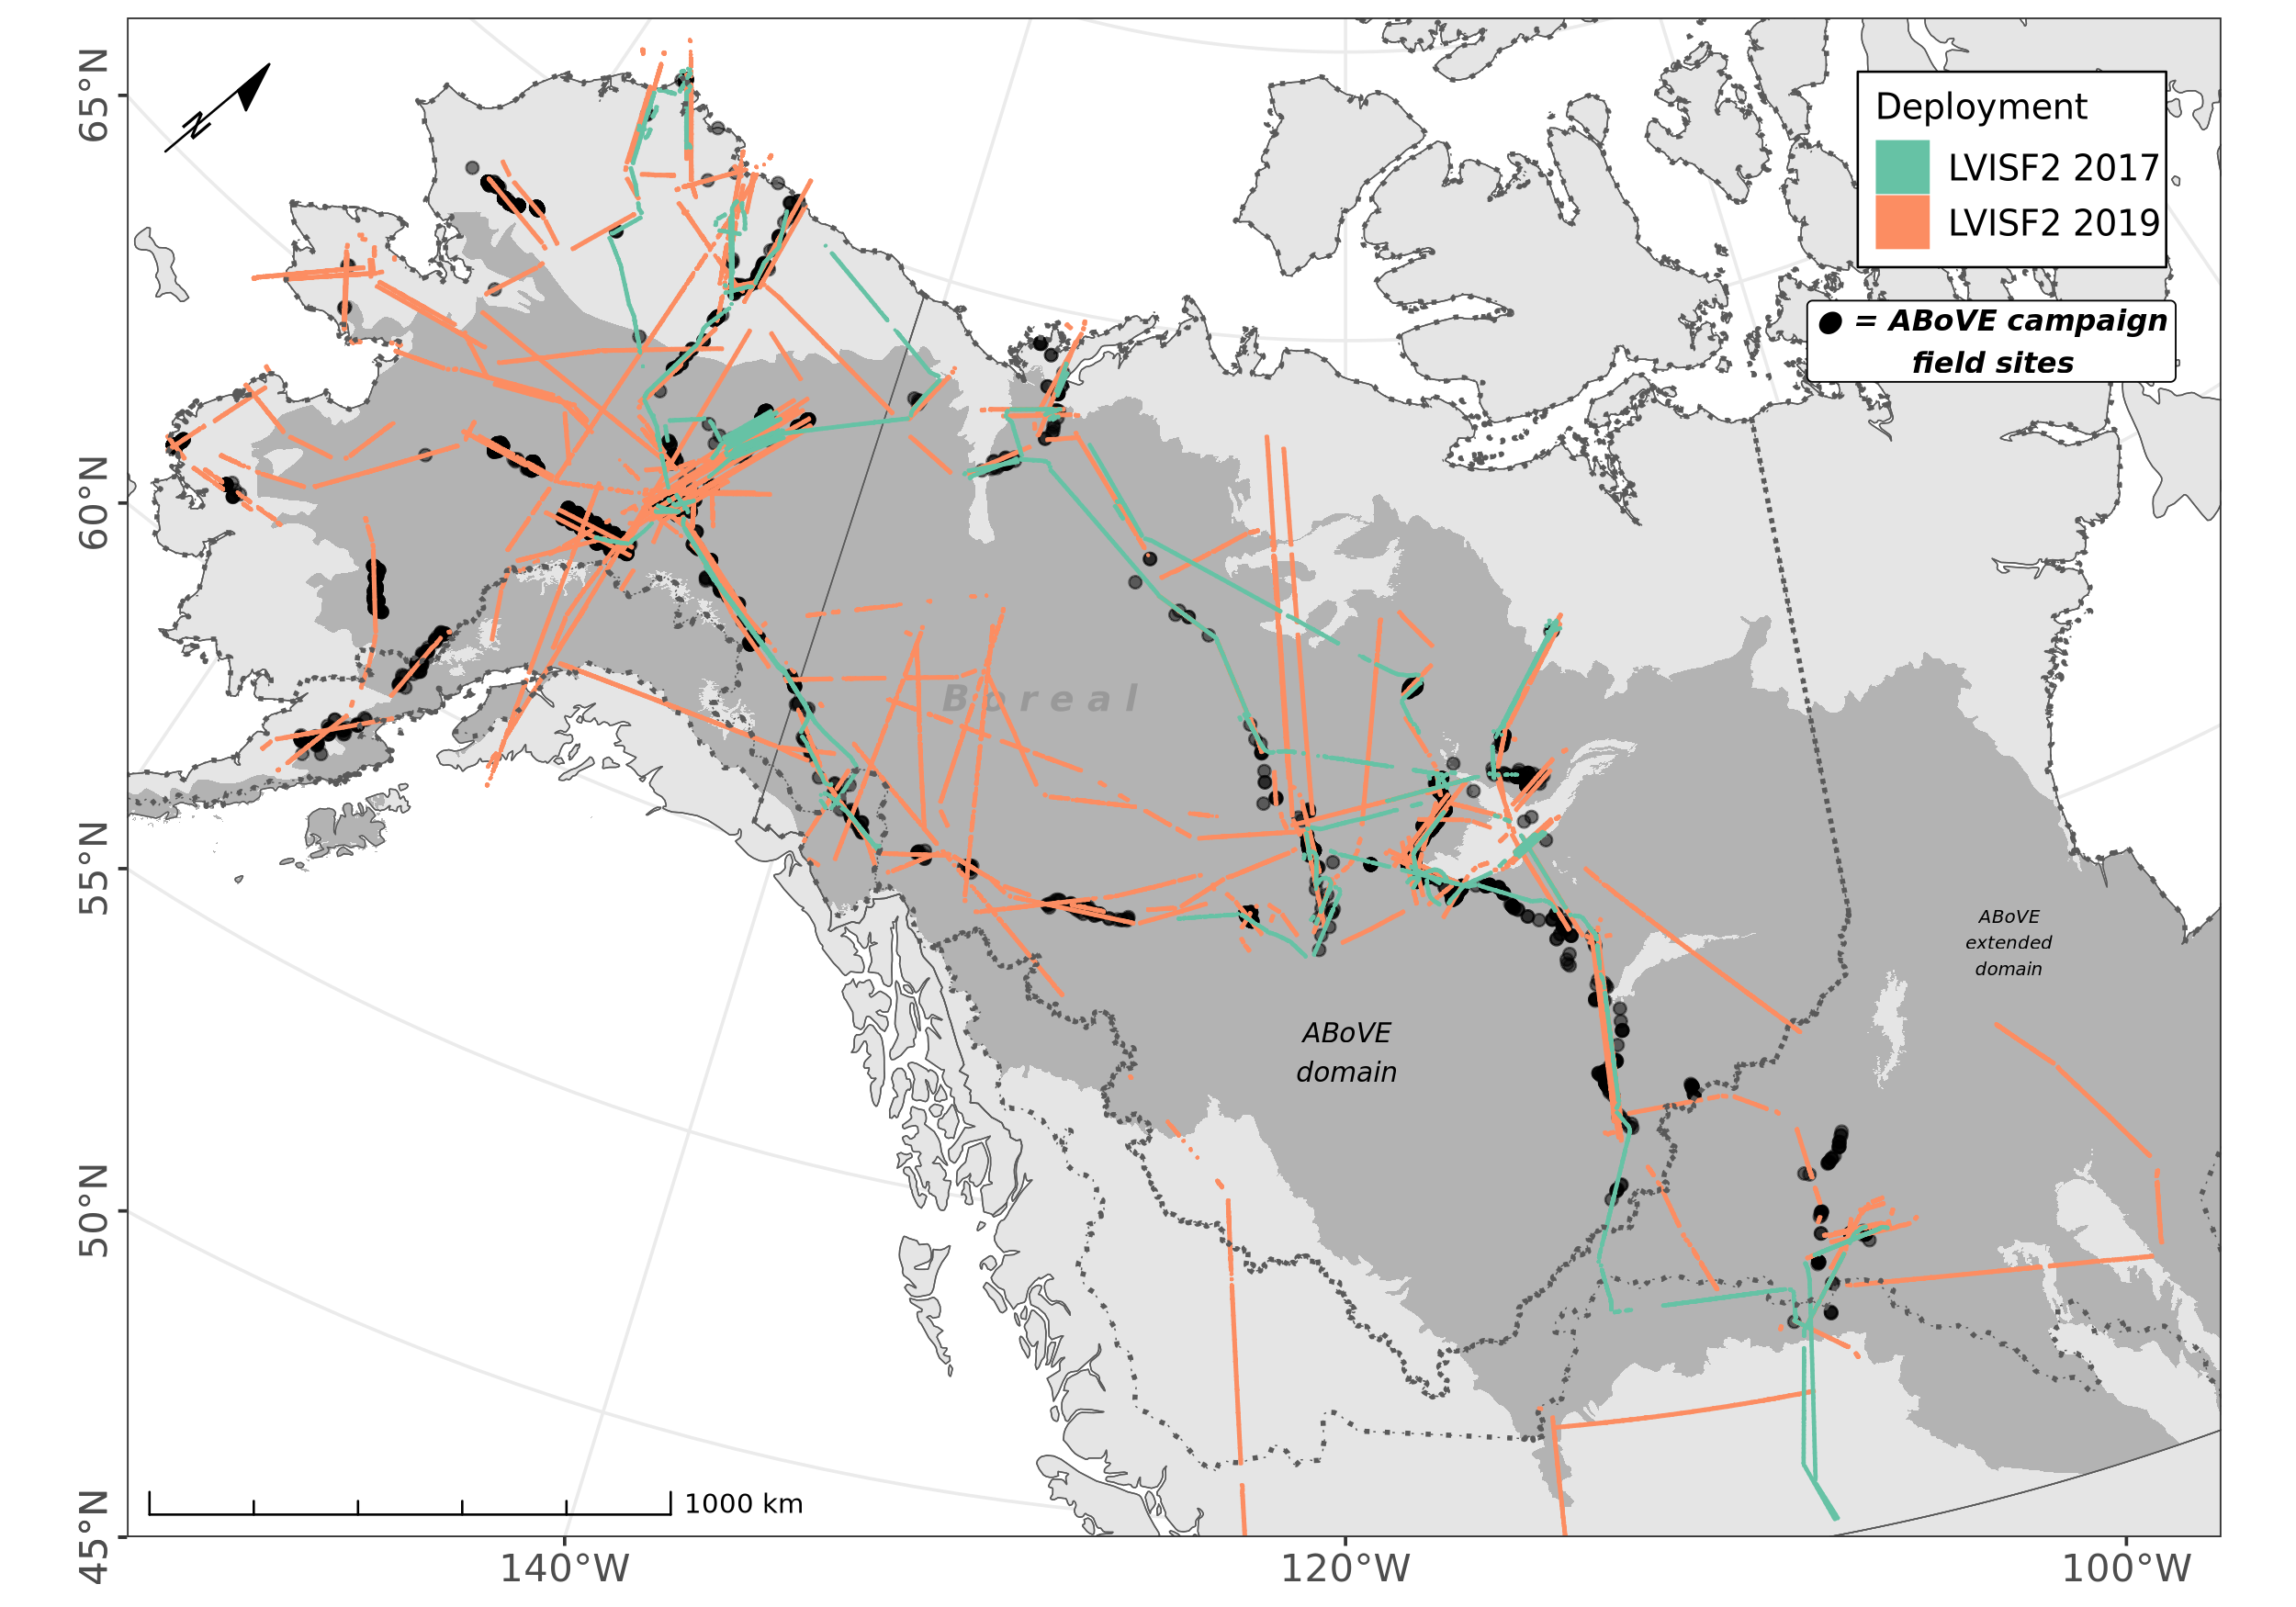

In [55]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 250, warn=-1)

map_list = list(
        annotation_scale(location = "bl", style="ticks"),
        annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal()),
        geom_sf(data = above_domain, fill=NA, linetype = "dotted", linewidth=0.75)
    )

# Create a data frame with latitude and longitude
point_data <- data.frame(
  name = '● = ABoVE campaign\nfield sites',
  # lon = -138,  # Washington DC longitude
  # lat = 65.5   # Washington DC latitude
    lon = -90,
    lat = 67.5
)

# Convert to sf object (Simple Features)
point_sf <- st_as_sf(point_data, 
                     coords = c("lon", "lat"), 
                     crs = 4326)  # WGS84 coordinate system

map_flightlines_overview = do_map_above_boreal(ABOVE_DOMAIN=TRUE) + 

    GET_CUSTOM_ABOVE_MAP(crs_canalb=crs_canalb) +
    #geom_sf(data=above_field_points, aes(color=`simple_name`), alpha=0.5) +
    geom_sf(data=above_field_points, color='black', alpha=0.5) +

    # For testing...
    #geom_sf(data=sample_n(lvis_footprints_trans,1000), aes(color=campaign, fill=campaign)) +

    # LVIS flightlines
    geom_sf(data=lvis_footprints_trans %>% filter(`Deployment`=='LVISF2 2019')
            , aes(color=`Deployment`, fill=`Deployment`), linewidth=0.5) +
    geom_sf(data=lvis_footprints_trans %>% filter(`Deployment`=='LVISF2 2017'), aes(color=`Deployment`, fill=`Deployment`), linewidth=0.5) +
    scale_fill_manual(values = c('black',"#B63679FF","#FB8861FF"), aesthetics = c("colour", "fill"), name=NULL) + 

    # details
    scale_fill_brewer(palette = 'Set2', aesthetics = c("colour", "fill"), name='Deployment  ') + 
    map_list +
    coord_sf(xlim=disp_win_coord[,'X'], ylim=disp_win_coord[,'Y'], crs=crs_canalb, expand=FALSE) +

      # Add the label
      geom_sf_label(data = point_sf, 
                    aes(label = name),
                    nudge_x = 0.5,  # Adjust label position
                    nudge_y = 0.5,
                    size = 3.25,
                    fontface = "bold.italic")

map_flightlines_overview

In [46]:
OUTDIR

[1] "/projects/my-public-bucket/above_lvis_flightlines/paper_figs"

In [47]:
Sys.Date()

[1] "2025-11-05"

In [56]:
ggsave(paste0(OUTDIR, "/above_map_lvis_flightlines_overview.png"), map_flightlines_overview, width = 10, height = 7, dpi = 250, bg='white')